In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob

# add parent folder (production) to sys.path
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from utils.LoRa import LoRa, MultiBAMv4

import importlib
import utils.my_lora_utils
importlib.reload(utils.my_lora_utils)
from utils.my_lora_utils import *

print(utils.my_lora_utils.__file__)

/home/gwon9906/LoRa-bam-reconstruction/utils/my_lora_utils.py


In [2]:
# LoRa 파라미터 설정 (generate.ipynb와 동일하게)
sf = 9
bw = 250_000  # 250 kHz
OSF = 4
fs = int(bw * OSF)  # 1 MHz

print(f"SF = {sf}, BW = {bw/1e3:.1f} kHz, fs = {fs/1e6:.3f} MHz")

# LoRa 인스턴스 생성 (on-the-fly 노이즈 추가용)
lora = LoRa(sf, bw)

SF = 9, BW = 250.0 kHz, fs = 1.000 MHz


In [3]:
########################################
##  Complex 스펙트로그램 생성 함수     ##
########################################

from scipy.signal import spectrogram, istft

def generate_complex_spectrogram(iq_signal, fs, bw=250_000, nperseg=256, noverlap=128, nfft=512):
    """
    복소 IQ 신호로부터 Complex 스펙트로그램 생성 (Phase 정보 보존)
    """
    # Complex 스펙트로그램 계산 (Phase 보존!)
    f, t, Zxx = spectrogram(
        iq_signal, 
        fs=fs, 
        window='hann',
        nperseg=nperseg, 
        noverlap=noverlap,
        nfft=nfft, 
        mode='complex',  # ← 핵심: Complex mode
        return_onesided=False
    )
    
    # 주파수 축 시프트 (DC를 중앙으로)
    f = np.fft.fftshift(f)
    Zxx = np.fft.fftshift(Zxx, axes=0)
    
    # 대역폭만큼 크롭
    mask = (f >= -bw/2) & (f < bw/2)
    Zxx_cropped = Zxx[mask, :]
    
    # Real/Imag 분리
    real_part = Zxx_cropped.real
    imag_part = Zxx_cropped.imag
    
    # 개별 정규화 (0-1 범위)
    r_min, r_max = real_part.min(), real_part.max()
    i_min, i_max = imag_part.min(), imag_part.max()
    
    real_norm = (real_part - r_min) / (r_max - r_min + 1e-12)
    imag_norm = (imag_part - i_min) / (i_max - i_min + 1e-12)
    
    # Real/Imag 통합 (Flatten)
    real_flat = real_norm.flatten()
    imag_flat = imag_norm.flatten()
    combined_flat = np.concatenate([real_flat, imag_flat])
    
    # 역변환을 위한 정보 저장
    norm_params = {
        'r_min': r_min, 'r_max': r_max,
        'i_min': i_min, 'i_max': i_max,
        'shape': Zxx_cropped.shape
    }
    
    return combined_flat, norm_params

print("✅ Complex 스펙트로그램 함수가 정의되었습니다 (Phase 보존)")


✅ Complex 스펙트로그램 함수가 정의되었습니다 (Phase 보존)


In [4]:
########################################
##  1. 클린 IQ 데이터 로드            ##
########################################

base_dir = "dataset_v4_sf9_bw250k"
iq_dir = os.path.join(base_dir, "clean_iq")

print("Loading clean IQ data...")
iq_files = sorted(glob.glob(os.path.join(iq_dir, "*.npy")))
print(f"Found {len(iq_files)} clean IQ files")

# 클린 IQ 로드
iq_data_list = []
for f in iq_files:
    x_clean = np.load(f)  # complex IQ
    iq_data_list.append(x_clean)

X_clean_iq = np.array(iq_data_list)  # shape: (512, 2048) or similar
print(f"Clean IQ shape: {X_clean_iq.shape}, dtype: {X_clean_iq.dtype}")


Loading clean IQ data...
Found 512 clean IQ files
Clean IQ shape: (512, 2048), dtype: complex64


In [ ]:
########################################
##  2. 데이터 증강 함수 정의          ##
########################################

# SNR 범위 설정 (Ultra-low SNR에 집중)
SNR_MIN = -25
SNR_MAX = -5
AUGMENT_FACTOR = 30  # 각 클린 IQ를 30배로 증강

def augment_dataset_denoising(X_clean_iq, augment_factor=30):
    """
    Denoising용: 클린 IQ를 N배로 증강하여 clean/noisy 쌍 생성
    Complex 스펙트로그램 사용 (Phase 정보 보존)
    
    Returns:
        X_clean_flat: (512*augment_factor, input_dim) 형태
        X_noisy_flat: (512*augment_factor, input_dim) 형태
        norm_params_list: 각 샘플의 역정규화 파라미터
    """
    print(f"\nGenerating {len(X_clean_iq)} × {augment_factor} = {len(X_clean_iq) * augment_factor} clean/noisy pairs...")
    
    X_clean_flat_list = []
    X_noisy_flat_list = []
    norm_params_list = []
    
    for clean_iq in X_clean_iq:
        for _ in range(augment_factor):
            # 랜덤 SNR 선택
            snr = np.random.randint(SNR_MIN, SNR_MAX + 1)
            
            # 노이즈 추가
            noisy_iq = lora.awgn_iq(clean_iq, snr)
            
            # Complex 스펙트로그램 생성 (Phase 보존)
            clean_flat, clean_params = generate_complex_spectrogram(clean_iq, fs, bw)
            noisy_flat, noisy_params = generate_complex_spectrogram(noisy_iq, fs, bw)
            
            X_clean_flat_list.append(clean_flat)
            X_noisy_flat_list.append(noisy_flat)
            norm_params_list.append(noisy_params)  # 복원 시 사용
    
    X_clean_flat = np.array(X_clean_flat_list)
    X_noisy_flat = np.array(X_noisy_flat_list)
    
    print(f"Clean dataset shape: {X_clean_flat.shape}")
    print(f"Noisy dataset shape: {X_noisy_flat.shape}")
    print(f"  - Real/Imag combined (Phase preserved)")
    
    return X_clean_flat, X_noisy_flat, norm_params_list

print(f"✅ Complex denoising augmentation function defined: {AUGMENT_FACTOR}x per clean IQ")

✅ Complex denoising augmentation function defined: 30x per clean IQ


In [ ]:
########################################
##  3. 모델 아키텍처 설정             ##
########################################

# Complex 스펙트로그램 shape 확인을 위한 테스트 (1개만)
test_spec_flat, test_params = generate_complex_spectrogram(X_clean_iq[0], fs, bw)
input_dim = test_spec_flat.shape[0]  # Real + Imag 통합 (2배)

# 점진적 압축 (입력 크기에 따라 자동 조정)
if input_dim > 6000:
    # 큰 입력 (7936): 7936 → 4096 → 3072 → 2048
    hidden_dims = [4096, 3072, 2048]
else:
    # 작은 입력 (3840): 3840 → 3072 → 2560 → 2048
    hidden_dims = [3072, 2560, 2048]

print(f"Complex spectrogram shape: {test_params['shape']}")
print(f"Input dim (Real+Imag): {input_dim}")
print(f"Model architecture: {input_dim} → {' → '.join(map(str, hidden_dims))}")
print(f"Compression ratio: {input_dim / hidden_dims[-1]:.1f}x")
print(f"Layers: {len(hidden_dims)} hidden layers (점진적 압축)")


Complex spectrogram shape: (128, 15)
Input dim (Real+Imag): 3840
Model architecture: 3840 → 4096 → 1024
Compression ratio: 3.8x



=== Training BAMv4 Denoising Model (Complex Spectrogram) ===
Architecture: 3840 → 4096 → 1024
Strategy: On-the-fly 30x Augmentation per Epoch (Phase Preserved)
Device: cuda

=== Starting Training with On-the-fly Complex Augmentation ===
Base samples: 512
Augmentation factor: 30x
Total per epoch: 15360

Epoch 1/20

Generating 512 × 30 = 15360 clean/noisy pairs...
Clean dataset shape: (15360, 3840)
Noisy dataset shape: (15360, 3840)
  - Real/Imag combined (Phase preserved)
[MultiBAMv4] Epoch 1/1 | MSE = 0.251951

Epoch 2/20

Generating 512 × 30 = 15360 clean/noisy pairs...
Clean dataset shape: (15360, 3840)
Noisy dataset shape: (15360, 3840)
  - Real/Imag combined (Phase preserved)
[MultiBAMv4] Epoch 1/1 | MSE = 0.275529

Epoch 3/20

Generating 512 × 30 = 15360 clean/noisy pairs...
Clean dataset shape: (15360, 3840)
Noisy dataset shape: (15360, 3840)
  - Real/Imag combined (Phase preserved)
[MultiBAMv4] Epoch 1/1 | MSE = 0.287407

Epoch 4/20

Generating 512 × 30 = 15360 clean/noisy pair

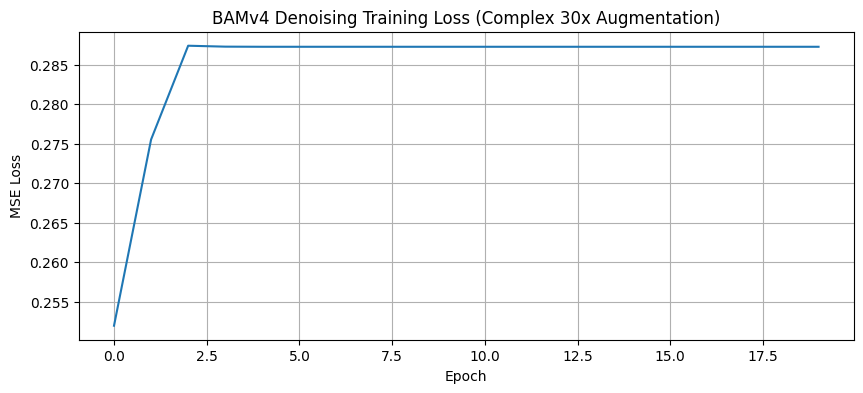

In [ ]:
########################################
##  4. BAMv4 Complex 30배 증강 학습  ##
########################################

print(f"\n=== Training BAMv4 Denoising Model (Complex Spectrogram) ===")
print(f"Architecture: {input_dim} → {' → '.join(map(str, hidden_dims))}")
print(f"Strategy: On-the-fly 30x Augmentation per Epoch (Phase Preserved)")

# BAMv4 모델 생성
model = MultiBAMv4(
    input_dim=input_dim,
    hidden_dims=hidden_dims,
    activation="tanh",
    device=None  # auto-detect cuda/cpu
)

print(f"Device: {model.device}")

# 학습 플래그
TRAIN = True  # 테스트 전에는 False

if TRAIN:
    print("\n=== Starting Training with On-the-fly Complex Augmentation ===")
    print(f"Base samples: {len(X_clean_iq)}")
    print(f"Augmentation factor: {AUGMENT_FACTOR}x")
    print(f"Total per epoch: {len(X_clean_iq) * AUGMENT_FACTOR}")
    
    # 학습 파라미터
    num_epochs = 20
    batch_size = 128
    lr = 5e-4  # 3-layer에 맞춰 학습률 조정
    
    all_losses = []
    
    # 매 epoch마다 새로운 노이즈로 증강
    for epoch in range(num_epochs):
        print(f"\n{'='*60}")
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"{'='*60}")
        
        # 30배 증강된 Complex clean/noisy 쌍 생성 (매 epoch마다 다른 노이즈!)
        X_clean_aug, X_noisy_aug, _ = augment_dataset_denoising(X_clean_iq, AUGMENT_FACTOR)
        
        # 1 epoch만 학습 (이미 증강된 데이터로)
        history = model.fit_denoise(
            X_noisy=X_noisy_aug,
            X_clean=X_clean_aug,
            num_epochs=1,
            batch_size=batch_size,
            lr=lr,
            weight_decay=0.0,
            verbose=True
        )
        
        all_losses.extend(history)
    
    print("\n=== Training Complete ===")
    
    # Loss 플롯
    plt.figure(figsize=(10, 4))
    plt.plot(all_losses)
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('BAMv4 Denoising Training Loss (Complex 30x Augmentation)')
    plt.grid(True)
    plt.show()
else:
    print("\nTraining skipped (TRAIN=False)")

In [8]:
########################################
##  5. 모델 저장                     ##
########################################

import torch

if TRAIN:
    # 모델 저장 폴더
    weight_folder = "weights_bamv4_complex"
    os.makedirs(weight_folder, exist_ok=True)
    
    # PyTorch 모델 전체 저장
    model_path = os.path.join(weight_folder, "multibam_v4_denoise.pth")
    torch.save(model.state_dict(), model_path)
    print(f"\n✅ Model saved to: {model_path}")
    
    # 아키텍처 정보도 함께 저장
    config = {
        'input_dim': input_dim,
        'hidden_dims': hidden_dims,
        'activation': 'tanh',
        'sf': sf,
        'bw': bw,
        'fs': fs,
        'mode': 'complex'  # Complex 방식 표시
    }
    config_path = os.path.join(weight_folder, "model_config.npy")
    np.save(config_path, config)
    print(f"✅ Config saved to: {config_path}")
    
print("\n=== How to Load Model ===")
print("""
# 모델 로드 예시:
config = np.load('weights_bamv4/model_config.npy', allow_pickle=True).item()
model = MultiBAMv4(
    input_dim=config['input_dim'],
    hidden_dims=config['hidden_dims'],
    activation=config['activation']
)
model.load_state_dict(torch.load('weights_bamv4/multibam_v4_denoise.pth'))
model.eval()
""")



✅ Model saved to: weights_bamv4_complex/multibam_v4_denoise.pth
✅ Config saved to: weights_bamv4_complex/model_config.npy

=== How to Load Model ===

# 모델 로드 예시:
config = np.load('weights_bamv4/model_config.npy', allow_pickle=True).item()
model = MultiBAMv4(
    input_dim=config['input_dim'],
    hidden_dims=config['hidden_dims'],
    activation=config['activation']
)
model.load_state_dict(torch.load('weights_bamv4/multibam_v4_denoise.pth'))
model.eval()




=== Testing Complex Denoising ===
Test symbol: 42, SNR: -10 dB
✅ IQ signal denoised: (1792,)


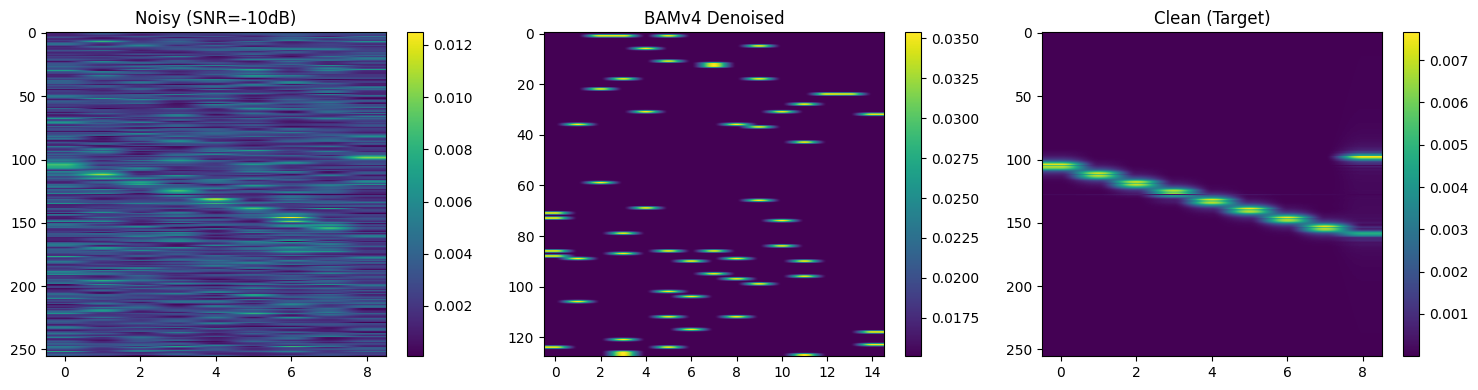

In [ ]:
########################################
##  6. 테스트: Complex 복원 및 IQ 재구성  ##
########################################

# 테스트 샘플 선택
test_symbol = 42  # 테스트할 심볼 (0~511)
test_snr = -10    # 테스트 SNR

print(f"\n=== Testing Complex Denoising ===")
print(f"Test symbol: {test_symbol}, SNR: {test_snr} dB")

# 1. 클린 IQ 생성
clean_iq = X_clean_iq[test_symbol]

# 2. 노이즈 추가
noisy_iq = lora.awgn_iq(clean_iq, test_snr)

# 3. Complex 스펙트로그램 생성
noisy_flat, noisy_params = generate_complex_spectrogram(noisy_iq, fs, bw)
clean_flat, clean_params = generate_complex_spectrogram(clean_iq, fs, bw)

# 4. BAMv4 Denoising
denoised_flat = model.reconstruct_numpy(noisy_flat.reshape(1, -1)).flatten()

# 5. Real/Imag 분리 및 역정규화
mid = len(denoised_flat) // 2
real_denoised_norm = denoised_flat[:mid].reshape(noisy_params['shape'])
imag_denoised_norm = denoised_flat[mid:].reshape(noisy_params['shape'])

# 역정규화
real_denoised = real_denoised_norm * (noisy_params['r_max'] - noisy_params['r_min']) + noisy_params['r_min']
imag_denoised = imag_denoised_norm * (noisy_params['i_max'] - noisy_params['i_min']) + noisy_params['i_min']

# 6. Complex 재결합
Zxx_denoised = real_denoised + 1j * imag_denoised

# 7. 역 STFT로 IQ 신호 복원
Zxx_unshifted = np.fft.ifftshift(Zxx_denoised, axes=0)
_, iq_denoised = istft(
    Zxx_unshifted, 
    fs=fs, 
    window='hann',
    nperseg=256, 
    noverlap=128,
    nfft=512, 
    input_onesided=False
)

print(f"✅ IQ signal denoised: {iq_denoised.shape}")

# 시각화: Magnitude 스펙트로그램 비교 (모두 같은 파라미터 + BW 크롭)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Noisy 스펙트로그램 (BW 크롭 적용)
f_n, t_n, Zxx_noisy_full = spectrogram(noisy_iq, fs, window='hann', nperseg=256, noverlap=128, nfft=512, mode='complex', return_onesided=False)
f_n = np.fft.fftshift(f_n)
Zxx_noisy_full = np.fft.fftshift(Zxx_noisy_full, axes=0)
mask_n = (f_n >= -bw/2) & (f_n < bw/2)
Zxx_noisy = Zxx_noisy_full[mask_n, :]
im1 = axes[0].imshow(np.abs(Zxx_noisy), aspect='auto', cmap='viridis', origin='lower')
axes[0].set_title(f'Noisy (SNR={test_snr}dB)')
plt.colorbar(im1, ax=axes[0])

# Denoised 스펙트로그램 (이미 크롭됨)
im2 = axes[1].imshow(np.abs(Zxx_denoised), aspect='auto', cmap='viridis', origin='lower')
axes[1].set_title('BAMv4 Denoised')
plt.colorbar(im2, ax=axes[1])

# Clean 스펙트로그램 (BW 크롭 적용)
f_c, t_c, Zxx_clean_full = spectrogram(clean_iq, fs, window='hann', nperseg=256, noverlap=128, nfft=512, mode='complex', return_onesided=False)
f_c = np.fft.fftshift(f_c)
Zxx_clean_full = np.fft.fftshift(Zxx_clean_full, axes=0)
mask_c = (f_c >= -bw/2) & (f_c < bw/2)
Zxx_clean = Zxx_clean_full[mask_c, :]
im3 = axes[2].imshow(np.abs(Zxx_clean), aspect='auto', cmap='viridis', origin='lower')
axes[2].set_title('Clean (Target)')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()


In [10]:
########################################
##  7. Dechirp 및 Code 복원 평가     ##
########################################

from utils.my_lora_utils import estimate_symbol_custom

print("\n=== Dechirp Code Reconstruction Test ===")

# 신호 길이 맞추기 (STFT/iSTFT로 인한 길이 차이 보정)
target_len = len(clean_iq)
if len(iq_denoised) < target_len:
    # Zero-padding (뒤쪽에 0 추가)
    iq_denoised = np.pad(iq_denoised, (0, target_len - len(iq_denoised)), mode='constant')
    print(f"⚠️  iq_denoised padded: {len(iq_denoised)} samples")
elif len(iq_denoised) > target_len:
    # 잘라내기
    iq_denoised = iq_denoised[:target_len]
    print(f"⚠️  iq_denoised truncated: {len(iq_denoised)} samples")
else:
    print(f"✅ Signal lengths match: {len(iq_denoised)} samples")

# 1. 원본 클린 신호 Dechirp
code_clean, peak_clean = estimate_symbol_custom(clean_iq, "clean", sf, fs, bw, tresshold=0)
print(f"✅ Clean signal    → Code: {code_clean}, Peak: {peak_clean:.2f}")

# 2. 노이즈 신호 Dechirp
code_noisy, peak_noisy = estimate_symbol_custom(noisy_iq, "noisy", sf, fs, bw, tresshold=0)
print(f"❌ Noisy signal    → Code: {code_noisy}, Peak: {peak_noisy:.2f}")

# 3. BAMv4 디노이즈 신호 Dechirp
code_denoised, peak_denoised = estimate_symbol_custom(iq_denoised, "denoised", sf, fs, bw, tresshold=0)
print(f"🔧 Denoised signal → Code: {code_denoised}, Peak: {peak_denoised:.2f}")

# 4. 성능 평가
print(f"\n{'='*60}")
print(f"Performance Evaluation:")
print(f"{'='*60}")
print(f"Ground Truth Symbol: {test_symbol}")
print(f"Clean Decoded:       {code_clean} {'✅ CORRECT' if code_clean == test_symbol else '❌ WRONG'}")
print(f"Noisy Decoded:       {code_noisy} {'✅ CORRECT' if code_noisy == test_symbol else '❌ WRONG'}")
print(f"Denoised Decoded:    {code_denoised} {'✅ CORRECT' if code_denoised == test_symbol else '❌ WRONG'}")
print(f"{'='*60}")

# Peak 비교
print(f"\nPeak Comparison:")
print(f"Clean Peak:    {peak_clean:.2f}")
print(f"Noisy Peak:    {peak_noisy:.2f} ({peak_noisy/peak_clean*100:.1f}% of clean)")
print(f"Denoised Peak: {peak_denoised:.2f} ({peak_denoised/peak_clean*100:.1f}% of clean)")

if code_denoised == test_symbol:
    print(f"\n✅ SUCCESS: BAMv4 successfully denoised and restored the correct symbol!")
else:
    print(f"\n❌ FAILURE: BAMv4 failed to restore the correct symbol")



=== Dechirp Code Reconstruction Test ===
⚠️  iq_denoised padded: 2048 samples
1879.9999977365217
168.000000035629
2047.9999977721507
✅ Clean signal    → Code: 42, Peak: 1066.00
1931.4506364994952
342.27718152891254
2199.9033271604085
❌ Noisy signal    → Code: 42, Peak: 1066.00
5.271000812203269
2.6447002829148314
5.715662164239644
🔧 Denoised signal → Code: 397, Peak: 1421.00

Performance Evaluation:
Ground Truth Symbol: 42
Clean Decoded:       42 ✅ CORRECT
Noisy Decoded:       42 ✅ CORRECT
Denoised Decoded:    397 ❌ WRONG

Peak Comparison:
Clean Peak:    1066.00
Noisy Peak:    1066.00 (100.0% of clean)
Denoised Peak: 1421.00 (133.3% of clean)

❌ FAILURE: BAMv4 failed to restore the correct symbol


In [ ]:
########################################
##  8. 정량적 성능 평가 (다중 샘플)  ##
########################################

print("\n" + "="*70)
print("📊 QUANTITATIVE PERFORMANCE EVALUATION (BAMv4)")
print("="*70)

# 테스트 파라미터
NUM_TEST_SAMPLES = 100  # 테스트할 샘플 수
TEST_SNR_LEVELS = [-25, -20, -15, -10, -5]  # 다양한 SNR 레벨

results = {snr: {'correct': 0, 'total': 0, 'mse': [], 'peak_ratio': []} for snr in TEST_SNR_LEVELS}

print(f"\n🧪 Testing with {NUM_TEST_SAMPLES} samples at each SNR level...")
print(f"SNR levels: {TEST_SNR_LEVELS} dB\n")

for snr in TEST_SNR_LEVELS:
    print(f"\n{'─'*70}")
    print(f"Testing SNR = {snr} dB")
    print(f"{'─'*70}")
    
    for i in range(NUM_TEST_SAMPLES):
        # 랜덤 심볼 선택
        test_sym = np.random.randint(0, 512)
        
        # 1. 클린 IQ
        clean_iq_test = X_clean_iq[test_sym]
        
        # 2. 노이즈 추가
        noisy_iq_test = lora.awgn_iq(clean_iq_test, snr)
        
        # 3. Complex 스펙트로그램 생성
        noisy_flat, noisy_params = generate_complex_spectrogram(noisy_iq_test, fs, bw)
        
        # 4. BAMv4 Denoising
        denoised_flat = model.reconstruct_numpy(noisy_flat.reshape(1, -1)).flatten()
        
        # 5. 역변환
        mid = len(denoised_flat) // 2
        real_denoised_norm = denoised_flat[:mid].reshape(noisy_params['shape'])
        imag_denoised_norm = denoised_flat[mid:].reshape(noisy_params['shape'])
        
        # 역정규화
        real_denoised = real_denoised_norm * (noisy_params['r_max'] - noisy_params['r_min']) + noisy_params['r_min']
        imag_denoised = imag_denoised_norm * (noisy_params['i_max'] - noisy_params['i_min']) + noisy_params['i_min']
        
        # Complex 재결합
        Zxx_denoised = real_denoised + 1j * imag_denoised
        
        # 6. 역 STFT
        Zxx_unshifted = np.fft.ifftshift(Zxx_denoised, axes=0)
        _, iq_denoised_test = istft(
            Zxx_unshifted, 
            fs=fs, 
            window='hann',
            nperseg=256, 
            noverlap=128,
            nfft=512, 
            input_onesided=False
        )
        
        # 길이 맞추기
        target_len = len(clean_iq_test)
        if len(iq_denoised_test) < target_len:
            iq_denoised_test = np.pad(iq_denoised_test, (0, target_len - len(iq_denoised_test)), mode='constant')
        elif len(iq_denoised_test) > target_len:
            iq_denoised_test = iq_denoised_test[:target_len]
        
        # 7. Dechirp
        try:
            code_clean, peak_clean = estimate_symbol_custom(clean_iq_test, "clean", sf, fs, bw, tresshold=0)
            code_denoised, peak_denoised = estimate_symbol_custom(iq_denoised_test, "denoised", sf, fs, bw, tresshold=0)
            
            # 정확도 체크
            if code_denoised == test_sym:
                results[snr]['correct'] += 1
            results[snr]['total'] += 1
            
            # Peak ratio
            if peak_clean > 0:
                results[snr]['peak_ratio'].append(peak_denoised / peak_clean)
            
            # MSE 계산
            mse = np.mean(np.abs(iq_denoised_test - clean_iq_test)**2)
            results[snr]['mse'].append(mse)
            
        except Exception as e:
            print(f"  ⚠️ Error at sample {i}: {e}")
            results[snr]['total'] += 1
    
    # 중간 결과 출력
    acc = results[snr]['correct'] / results[snr]['total'] * 100
    avg_mse = np.mean(results[snr]['mse']) if results[snr]['mse'] else 0
    avg_peak = np.mean(results[snr]['peak_ratio']) if results[snr]['peak_ratio'] else 0
    
    print(f"  ✓ Accuracy: {results[snr]['correct']}/{results[snr]['total']} = {acc:.1f}%")
    print(f"  ✓ Avg MSE: {avg_mse:.6f}")
    print(f"  ✓ Avg Peak Ratio: {avg_peak:.2%}")

# 최종 결과 요약
print("\n" + "="*70)
print("📈 FINAL RESULTS SUMMARY (BAMv4)")
print("="*70)

print(f"\n{'SNR (dB)':<10} {'Accuracy':<15} {'MSE':<15} {'Peak Ratio':<15}")
print("─"*70)

for snr in TEST_SNR_LEVELS:
    acc = results[snr]['correct'] / results[snr]['total'] * 100
    avg_mse = np.mean(results[snr]['mse']) if results[snr]['mse'] else 0
    avg_peak = np.mean(results[snr]['peak_ratio']) if results[snr]['peak_ratio'] else 0
    
    print(f"{snr:<10} {acc:>6.1f}%{'':<8} {avg_mse:>8.6f}{'':<6} {avg_peak:>6.1%}{'':<8}")

# 전체 평균
total_correct = sum(r['correct'] for r in results.values())
total_samples = sum(r['total'] for r in results.values())
overall_acc = total_correct / total_samples * 100

print("─"*70)
print(f"{'Overall':<10} {overall_acc:>6.1f}%")
print("="*70)

# 시각화
plt.figure(figsize=(15, 4))

# 1. Accuracy vs SNR
plt.subplot(1, 3, 1)
snrs = TEST_SNR_LEVELS
accs = [results[snr]['correct'] / results[snr]['total'] * 100 for snr in snrs]
plt.plot(snrs, accs, 'o-', linewidth=2, markersize=8)
plt.xlabel('SNR (dB)')
plt.ylabel('Accuracy (%)')
plt.title('Symbol Classification Accuracy (BAMv4)')
plt.grid(True, alpha=0.3)
plt.ylim([0, 105])

# 2. MSE vs SNR
plt.subplot(1, 3, 2)
mses = [np.mean(results[snr]['mse']) for snr in snrs]
plt.plot(snrs, mses, 's-', linewidth=2, markersize=8, color='orange')
plt.xlabel('SNR (dB)')
plt.ylabel('MSE')
plt.title('Denoising MSE')
plt.grid(True, alpha=0.3)
plt.yscale('log')

# 3. Peak Ratio vs SNR
plt.subplot(1, 3, 3)
peaks = [np.mean(results[snr]['peak_ratio']) * 100 for snr in snrs]
plt.plot(snrs, peaks, '^-', linewidth=2, markersize=8, color='green')
plt.xlabel('SNR (dB)')
plt.ylabel('Peak Ratio (%)')
plt.title('Peak Recovery Ratio')
plt.grid(True, alpha=0.3)
plt.axhline(y=100, color='r', linestyle='--', alpha=0.5, label='Perfect (100%)')
plt.legend()

plt.tight_layout()
plt.show()

print(f"\n✅ Quantitative evaluation complete!")
